# Bandits Demo — Comparing Linear Bandit (Ridge/ARD) and Forest Bandit

No PyTorch. Pure numpy + scipy + sklearn.

Compares the new bandit proposal modes against each other on the same UO₂ dataset.

In [20]:
# =============================================================================
# IMPORTS & CONFIGURATION
# =============================================================================
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import BayesianRidge, ARDRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error

from lordcapulet.data_structures.databank import DataBank
from lordcapulet.functions.proposal_modes.shared_functionality import create_patchwork_guess
from lordcapulet.functions.proposal_modes.Bandits_shared import boltzmann_sample, lcb_acquisition

# ---- Shared config -----------------------------------------------------------
# DATA_FILE = "../Bayesian/UO2_scan_data_extractor_so_n_converted.json"
DATA_FILE = "./ErI3_scan_random.json"
NUM_PROPOSALS = 10
ENSAMBLE_SIZE = 20000
ETA = 30.0
BETA = 0.5

# ---- Feature toggles ---------------------------------------------------------
# Configured to match the old analysis feature set 1:1:
#   E_total = const + (U/2)·hubbard_term + (-J/4)·hund_term_M2
#             + Σ J_H·heisenberg_{i}_{j} + Σ c_{ij}·cf_atom*_n_*_*
FEATURE_FLAGS = {
    # Total (up+down) occupation matrix per atom, upper triangle.
    # Old analysis: cf_atom{k}_n_{i}_{j}  (USE_CRYSTAL_FIELD=True)
    "include_raw_occ_total": True,
    "include_raw_occ_offdiag": True,   # USE_CF_OFFDIAGONAL=True
    # Per-spin raw occupation (NOT used in old analysis)
    "include_raw_occ": False,
    # Global Hubbard term: Σ tr[n(1-n)] across all atoms → 1 feature.
    # Old analysis: hubbard_term  (USE_HUBBARD=True)
    "include_hubbard_global": False,
    "include_hubbard": True,
    # Global Hund term: Σ M² across all atoms → 1 feature.
    # Old analysis: hund_term_M2  (USE_HUND=True)
    "include_hund_global": False,
    "include_hund_per_atom": True,
    # Heisenberg per pair: m_i · m_j.  (USE_HEISENBERG=True)
    "include_heisenberg": True,
    # Extra features (not in old analysis)
    "include_trace_per_spin": False,
    "include_moment_per_atom": False,
    "include_pair_products": False,
}

# ---- Model-specific kwargs ---------------------------------------------------
RIDGE_KWARGS = dict(tol=1e-6, alpha_1=1e-6, alpha_2=1e-6,
                    lambda_1=1e-6, lambda_2=1e-6, fit_intercept=True)
ARD_KWARGS = dict(tol=1e-6, alpha_1=1e-6, alpha_2=1e-6,
                  lambda_1=1e-6, lambda_2=1e-6, threshold_lambda=100000.0,
                  fit_intercept=True)
RF_KWARGS = dict(n_estimators=300, max_depth=None, min_samples_leaf=2,
                 n_jobs=-1, oob_score=True, random_state=42)

# ---- Patchwork params --------------------------------------------------------
PATCHWORK_PARAMS = dict(apply_rotation=True, rotation_prob=0.2,
                        rotation_type="Mixed")

print("Configuration loaded.")
print(f"Data: {DATA_FILE}")
print(f"Ensemble size: {ENSAMBLE_SIZE}  |  β={BETA}  |  η={ETA}")
print(f"Feature groups: {[k for k, v in FEATURE_FLAGS.items() if v]}")


Configuration loaded.
Data: ./ErI3_scan_random.json
Ensemble size: 20000  |  β=0.5  |  η=30.0
Feature groups: ['include_raw_occ_total', 'include_raw_occ_offdiag', 'include_hubbard', 'include_hund_per_atom', 'include_heisenberg']


## Data Loading & Featurization

In [27]:
from sklearn.model_selection import train_test_split

# Load data
databank = DataBank.from_json(DATA_FILE, only_converged=True)
atoms = databank.atom_ids
n_total = len(databank)

# Random train/test split on indices (matching old analysis approach)
idx_all = np.arange(n_total)
idx_train, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42)

train_db = databank[idx_train]
test_db = databank[idx_test]

# Build feature matrices
X_train, feature_names = train_db.to_feature_matrix(atom_ids=atoms, **FEATURE_FLAGS)
y_train = train_db.energies
X_test, _ = test_db.to_feature_matrix(atom_ids=atoms, **FEATURE_FLAGS)
y_test = test_db.energies

print(f"Total calculations: {n_total}")
print(f"Atoms: {atoms}")
print(f"Train: {len(y_train)}  |  Test: {len(y_test)}")
print(f"Feature matrix: {X_train.shape[1]} features")
print(f"Train energy range: [{y_train.min():.2f}, {y_train.max():.2f}] eV")
print(f"Test energy range:  [{y_test.min():.2f}, {y_test.max():.2f}] eV")
print(f"\nFirst 10 feature names:")
for name in feature_names[:100]:
    print(f"  {name}")

Total calculations: 58
Atoms: ['Atom_1', 'Atom_2']
Train: 46  |  Test: 12
Feature matrix: 61 features
Train energy range: [-54332.54, -54327.97] eV
Test energy range:  [-54331.85, -54329.01] eV

First 10 feature names:
  cf_atom1_n_1_1
  cf_atom1_n_2_2
  cf_atom1_n_3_3
  cf_atom1_n_4_4
  cf_atom1_n_5_5
  cf_atom1_n_6_6
  cf_atom1_n_7_7
  cf_atom1_n_1_2
  cf_atom1_n_1_3
  cf_atom1_n_1_4
  cf_atom1_n_1_5
  cf_atom1_n_1_6
  cf_atom1_n_1_7
  cf_atom1_n_2_3
  cf_atom1_n_2_4
  cf_atom1_n_2_5
  cf_atom1_n_2_6
  cf_atom1_n_2_7
  cf_atom1_n_3_4
  cf_atom1_n_3_5
  cf_atom1_n_3_6
  cf_atom1_n_3_7
  cf_atom1_n_4_5
  cf_atom1_n_4_6
  cf_atom1_n_4_7
  cf_atom1_n_5_6
  cf_atom1_n_5_7
  cf_atom1_n_6_7
  cf_atom2_n_1_1
  cf_atom2_n_2_2
  cf_atom2_n_3_3
  cf_atom2_n_4_4
  cf_atom2_n_5_5
  cf_atom2_n_6_6
  cf_atom2_n_7_7
  cf_atom2_n_1_2
  cf_atom2_n_1_3
  cf_atom2_n_1_4
  cf_atom2_n_1_5
  cf_atom2_n_1_6
  cf_atom2_n_1_7
  cf_atom2_n_2_3
  cf_atom2_n_2_4
  cf_atom2_n_2_5
  cf_atom2_n_2_6
  cf_atom2_n_2_7

## 1. Bayesian Ridge Bandit

In [28]:
# Scale features
scaler_ridge = StandardScaler()
X_train_s = scaler_ridge.fit_transform(X_train)
X_test_s = scaler_ridge.transform(X_test)

# Fit Bayesian Ridge
ridge = BayesianRidge(**RIDGE_KWARGS)
ridge.fit(X_train_s, y_train)

# Predict on test set
y_pred_ridge, y_std_ridge = ridge.predict(X_test_s, return_std=True)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)

# Also in-sample for comparison
y_pred_train_ridge, _ = ridge.predict(X_train_s, return_std=True)
r2_train_ridge = r2_score(y_train, y_pred_train_ridge)

# --- Extract physics parameters from linear coefficients ---
coeff_ridge = dict(zip(feature_names, ridge.coef_))
hubb_ridge = [v for k, v in coeff_ridge.items() if k.startswith("hubbard_")]
hund_ridge = [v for k, v in coeff_ridge.items() if k.startswith("hund_M2_")]
U_ridge = 2.0 * np.mean(hubb_ridge) if hubb_ridge else float('nan')
J_ridge = -4.0 * np.mean(hund_ridge) if hund_ridge else float('nan')

print("--- Bayesian Ridge ---")
print(f"  Test R² = {r2_ridge:.4f}  |  Train R² = {r2_train_ridge:.4f}")
print(f"  Test RMSE = {rmse_ridge:.4f} eV")
print(f"  U_eff = {U_ridge:.4f} eV  ({[f'{c*2:.2f}' for c in hubb_ridge]})")
print(f"  J_eff = {J_ridge:.4f} eV  ({[f'{-c*4:.2f}' for c in hund_ridge]})")
print(f"  α = {ridge.alpha_:.4f}  |  λ = {ridge.lambda_:.4f}  |  intercept = {ridge.intercept_:.4f} eV")

# Top coefficients
for k, v in zip(feature_names, ridge.coef_):
    #if v != 0 and abs(v) > 1e-3:
        print(f"  {k:50s} {v:+.6e}")

--- Bayesian Ridge ---
  Test R² = 0.8953  |  Train R² = 0.9726
  Test RMSE = 0.2400 eV
  U_eff = 0.7946 eV  (['1.23', '0.36'])
  J_eff = 1.6923 eV  (['1.98', '1.40'])
  α = 15.0886  |  λ = 19.3603  |  intercept = -54331.1445 eV
  cf_atom1_n_1_1                                     +1.105648e-01
  cf_atom1_n_2_2                                     +2.211288e-02
  cf_atom1_n_3_3                                     +2.211288e-02
  cf_atom1_n_4_4                                     -3.587227e-02
  cf_atom1_n_5_5                                     -3.587227e-02
  cf_atom1_n_6_6                                     -3.831985e-03
  cf_atom1_n_7_7                                     -2.461374e-02
  cf_atom1_n_1_2                                     -1.873642e-02
  cf_atom1_n_1_3                                     +3.931376e-03
  cf_atom1_n_1_4                                     +2.493836e-02
  cf_atom1_n_1_5                                     -7.694449e-03
  cf_atom1_n_1_6                  

## 2. ARD Bandit (Automatic Relevance Determination)

In [29]:
# Scale
scaler_ard = StandardScaler()
# X_train_sa = scaler_ard.fit_transform(X_train)
# X_test_sa = scaler_ard.transform(X_test)

X_train_sa = X_train.copy()
X_test_sa = X_test.copy()

# Fit ARD
ard = ARDRegression(**ARD_KWARGS)
ard.fit(X_train_sa, y_train)

# Predict on test set
y_pred_ard, y_std_ard = ard.predict(X_test_sa, return_std=True)
r2_ard = r2_score(y_test, y_pred_ard)
rmse_ard = root_mean_squared_error(y_test, y_pred_ard)

# In-sample
y_pred_train_ard, _ = ard.predict(X_train_sa, return_std=True)
r2_train_ard = r2_score(y_train, y_pred_train_ard)

n_active = int(np.sum(np.abs(ard.coef_) > 1e-6))
n_total_f = len(ard.coef_)

# --- Extract physics parameters ---
coeff_ard = dict(zip(feature_names, ard.coef_))
hubb_ard = [v for k, v in coeff_ard.items() if k.startswith("hubbard_")]
hund_ard = [v for k, v in coeff_ard.items() if k.startswith("hund_M2_")]
U_ard = 2.0 * np.mean(hubb_ard) if hubb_ard else float('nan')
J_ard = -4.0 * np.mean(hund_ard) if hund_ard else float('nan')

print("--- ARD Regression ---")
print(f"  Test R² = {r2_ard:.4f}  |  Train R² = {r2_train_ard:.4f}")
print(f"  Test RMSE = {rmse_ard:.4f} eV")
print(f"  U_eff = {U_ard:.4f} eV  ({[f'{c*2:.2f}' for c in hubb_ard]})")
print(f"  J_eff = {J_ard:.4f} eV  ({[f'{-c*4:.2f}' for c in hund_ard]})")
print(f"  Features retained: {n_active} / {n_total_f}  ({n_total_f - n_active} pruned)")
print(f"  α = {ard.alpha_:.4f}  |  intercept = {ard.intercept_:.4f} eV")

# Top retained features
ard_abs = np.abs(ard.coef_)
top_idx = np.argsort(ard_abs)[-10:][::-1]
print(f"  Top-10 retained features (by |coeff|):")
for idx in top_idx:
    if ard_abs[idx] > 1e-6:
        print(f"    {feature_names[idx]:50s} {ard.coef_[idx]:+.6e}")

--- ARD Regression ---
  Test R² = 0.8687  |  Train R² = 0.9671
  Test RMSE = 0.2687 eV
  U_eff = 2.5064 eV  (['5.01', '0.00'])
  J_eff = 0.5824 eV  (['0.59', '0.58'])
  Features retained: 25 / 61  (36 pruned)
  α = 16.3122  |  intercept = -54330.0177 eV
  Top-10 retained features (by |coeff|):
    hubbard_Atom_1                                     +2.504843e+00
    cf_atom2_n_3_3                                     +3.874259e-01
    cf_atom2_n_2_2                                     +3.874259e-01
    cf_atom1_n_4_4                                     -3.575737e-01
    cf_atom1_n_5_5                                     -3.575737e-01
    hund_M2_Atom_1                                     -1.466581e-01
    hund_M2_Atom_2                                     -1.445538e-01
    cf_atom1_n_1_1                                     +1.340372e-01
    cf_atom1_n_7_7                                     -9.005928e-02
    cf_atom2_n_1_1                                     +1.862138e-02


## 3. Random Forest Bandit

In [30]:
# RF doesn't need scaling
rf = RandomForestRegressor(**RF_KWARGS)
rf.fit(X_train, y_train)

# OOB score (built-in unbiased estimate from training)
oob_r2 = rf.oob_score_

# Predict on test set
y_pred_rf = rf.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)

# In-sample for comparison
y_pred_train_rf = rf.predict(X_train)
r2_train_rf = r2_score(y_train, y_pred_train_rf)

# Uncertainty from tree std (on test set)
tree_preds_test = np.array([t.predict(X_test) for t in rf.estimators_])
y_std_rf = tree_preds_test.std(axis=0)

print("--- Random Forest ---")
print(f"  Test R² = {r2_rf:.4f}  |  Train R² = {r2_train_rf:.4f}  |  OOB R² = {oob_r2:.4f}")
print(f"  Test RMSE = {rmse_rf:.4f} eV")
print(f"  Trees: {RF_KWARGS['n_estimators']}")

# Top feature importances
importances = rf.feature_importances_
top_fi = np.argsort(importances)[-10:][::-1]
print(f"  Top-10 feature importances:")
for idx in top_fi:
    print(f"    {feature_names[idx]:50s} {importances[idx]:.4f}")

--- Random Forest ---
  Test R² = 0.7114  |  Train R² = 0.9466  |  OOB R² = 0.7132
  Test RMSE = 0.3984 eV
  Trees: 300
  Top-10 feature importances:
    hund_M2_Atom_1                                     0.4258
    hubbard_Atom_1                                     0.1741
    hund_M2_Atom_2                                     0.0805
    hubbard_Atom_2                                     0.0524
    heisenberg_1_2                                     0.0392
    cf_atom2_n_2_2                                     0.0303
    cf_atom2_n_3_3                                     0.0280
    cf_atom2_n_1_1                                     0.0188
    cf_atom2_n_1_6                                     0.0136
    cf_atom2_n_1_5                                     0.0106


## Model Comparison — Predictions vs Actual

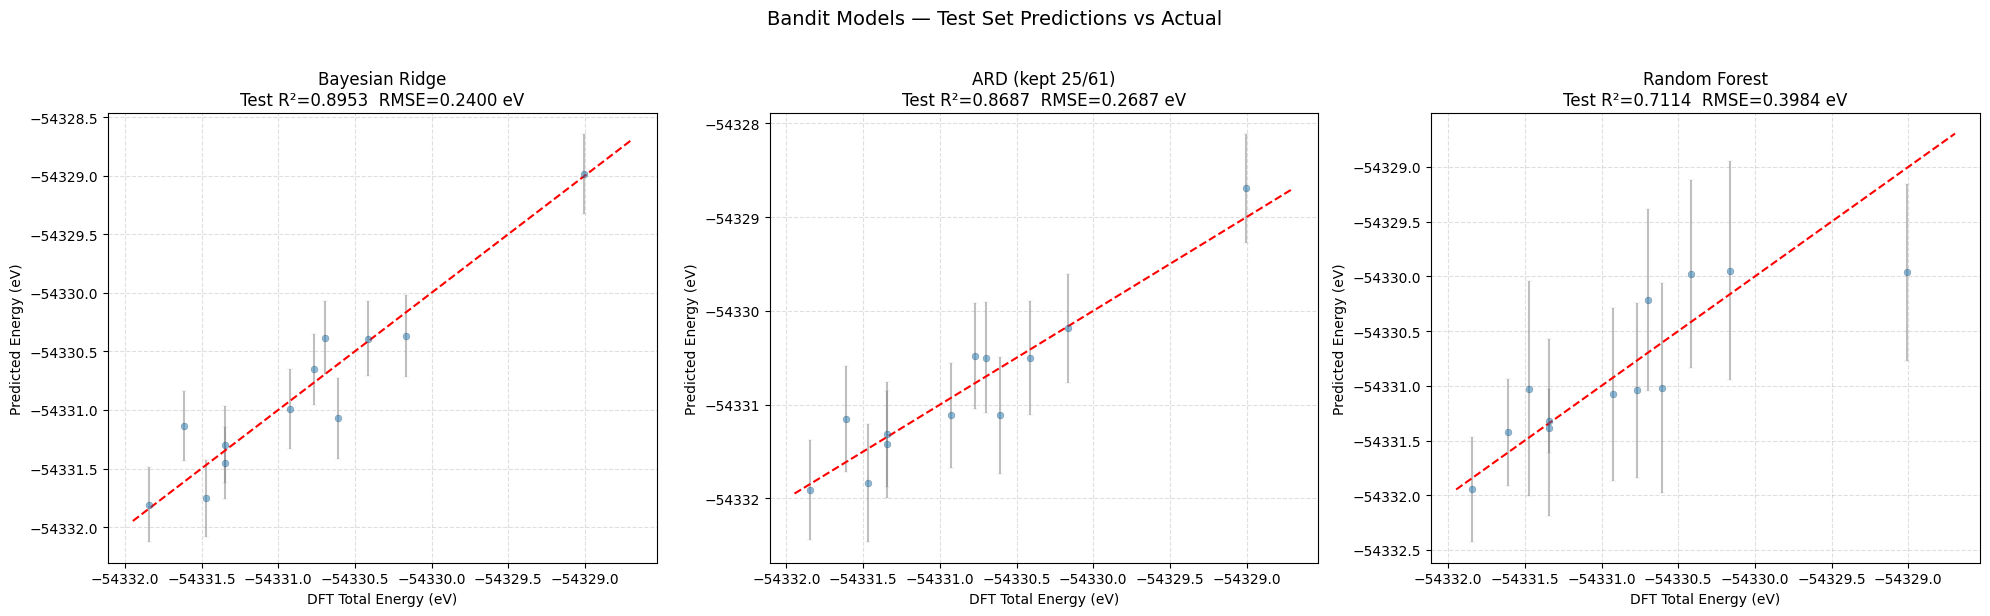

In [31]:
# 3-panel comparison plot — all on test set
models_data = [
    ("Bayesian Ridge", y_pred_ridge, y_std_ridge, r2_ridge, rmse_ridge),
    ("ARD (kept {}/{})".format(n_active, n_total_f), y_pred_ard, y_std_ard, r2_ard, rmse_ard),
    ("Random Forest", y_pred_rf, y_std_rf, r2_rf, rmse_rf),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
y_min = min([y_test.min()] + [yp.min() for _, yp, _, _, _ in models_data])
y_max = max([y_test.max()] + [yp.max() for _, yp, _, _, _ in models_data])

for ax, (name, y_pred, y_std, r2, rmse) in zip(axes, models_data):
    ax.errorbar(y_test, y_pred, yerr=y_std, fmt='o', alpha=0.5,
                ecolor='gray', capsize=2, markersize=5, markeredgewidth=0.2,
                markeredgecolor='black')
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', lw=1.5)
    ax.set_xlabel("DFT Total Energy (eV)")
    ax.set_ylabel("Predicted Energy (eV)")
    ax.set_title(f"{name}\nTest R²={r2:.4f}  RMSE={rmse:.4f} eV")
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle("Bandit Models — Test Set Predictions vs Actual", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Generate Candidates — Patchwork Ensemble + Boltzmann Sampling

In [19]:
# ---- Generate patchwork ensemble (shared across all models) ----
x_raw_train = train_db.to_numpy(atom_ids=atoms, spins=['up', 'down'])
ensamble_raw = np.empty((ENSAMBLE_SIZE, x_raw_train.shape[1]))

print(f"Generating {ENSAMBLE_SIZE} patchwork candidates...")
t0 = time.time()
for i in range(ENSAMBLE_SIZE):
    ensamble_raw[i, :] = create_patchwork_guess(
        train_db, x_raw_train, atoms,
        apply_rotation=PATCHWORK_PARAMS["apply_rotation"],
        rotation_prob=PATCHWORK_PARAMS["rotation_prob"],
        rotation_type=PATCHWORK_PARAMS["rotation_type"],
    )
t1 = time.time()
print(f"  Done in {t1 - t0:.1f} s")

# Convert ensemble raw → OccupationMatrixData → DataBank → featurize
ensamble_occ = databank.from_numpy(ensamble_raw, atom_ids=atoms, spins=['up', 'down'])
ensamble_db = DataBank.from_matrices(
    occ_matrices=ensamble_occ,
    energies=[0.0] * ENSAMBLE_SIZE,
)
X_ens, _ = ensamble_db.to_feature_matrix(atom_ids=atoms, **FEATURE_FLAGS)
print(f"Ensemble feature matrix: {X_ens.shape}")

Generating 20000 patchwork candidates...
  Done in 30.5 s
Ensemble feature matrix: (20000, 126)


In [20]:
def sample_candidates(model, X_ens, scaler=None, model_type="ridge"):
    """Predict μ, σ → LCB → Boltzmann sample → return (indices, mu, sigma, acq_scores)."""
    if scaler is not None:
        X_e = scaler.transform(X_ens)
    else:
        X_e = X_ens  # RF doesn't need scaling

    if model_type == "forest":
        tree_preds = np.array([t.predict(X_e) for t in model.estimators_])
        mu = tree_preds.mean(axis=0)
        sigma = tree_preds.std(axis=0)
    else:
        mu, sigma = model.predict(X_e, return_std=True)

    acq_scores = lcb_acquisition(mu, sigma, beta=BETA)
    # idx = boltzmann_sample(acq_scores, eta=ETA, num_samples=NUM_PROPOSALS, replacement=False)
    # choose best 10 for testing
    idx = np.argsort(-acq_scores)[:NUM_PROPOSALS]
    return idx, mu, sigma, acq_scores

# --- Sample from each model ---
idx_ridge, mu_r, sig_r, acq_r = sample_candidates(ridge, X_ens, scaler_ridge, "ridge")
idx_ard,   mu_a, sig_a, acq_a = sample_candidates(ard,   X_ens, scaler_ard,   "ridge")
idx_rf,    mu_f, sig_f, acq_f = sample_candidates(rf,    X_ens, None,          "forest")

# --- Summary ---
print("\n" + "=" * 90)
print("CANDIDATE COMPARISON — All Models")
print("=" * 90)
print(f"{'Rank':<5} {'Ridge μ':<10} {'Ridge σ':<10} {'ARD μ':<10} {'ARD σ':<10} {'RF μ':<10} {'RF σ':<10}")
print("-" * 90)
for rank in range(NUM_PROPOSALS):
    print(f"{rank:<5} {mu_r[idx_ridge[rank]]:<10.4f} {sig_r[idx_ridge[rank]]:<10.4f} "
          f"{mu_a[idx_ard[rank]]:<10.4f} {sig_a[idx_ard[rank]]:<10.4f} "
          f"{mu_f[idx_rf[rank]]:<10.4f} {sig_f[idx_rf[rank]]:<10.4f}")
print("=" * 90)

# Show which candidates overlap between models
ridge_set = set(idx_ridge)
ard_set = set(idx_ard)
rf_set = set(idx_rf)
print(f"\nOverlap: Ridge∩ARD={len(ridge_set & ard_set)}, "
      f"Ridge∩RF={len(ridge_set & rf_set)}, "
      f"ARD∩RF={len(ard_set & rf_set)}, "
      f"All3={len(ridge_set & ard_set & rf_set)}")


CANDIDATE COMPARISON — All Models
Rank  Ridge μ    Ridge σ    ARD μ      ARD σ      RF μ       RF σ      
------------------------------------------------------------------------------------------
0     -59739.4013 1.5385     -59738.6306 1.1578     -59738.4590 0.1674    
1     -59739.0565 1.9682     -59738.6374 1.1379     -59738.4615 0.1616    
2     -59739.0969 1.8545     -59738.6370 1.1311     -59738.4471 0.1859    
3     -59739.0777 1.8793     -59738.6280 1.1469     -59738.4742 0.1305    
4     -59739.1242 1.7178     -59738.5998 1.1452     -59738.4606 0.1549    
5     -59738.9916 1.9420     -59738.6755 0.9379     -59738.4097 0.2525    
6     -59739.1766 1.5361     -59738.5347 1.1873     -59738.4475 0.1711    
7     -59738.8984 2.0640     -59738.6278 0.9856     -59738.4576 0.1469    
8     -59738.8214 2.1816     -59738.5628 1.1064     -59738.4201 0.2205    
9     -59739.0408 1.7387     -59738.5828 1.0358     -59738.4268 0.2066    

Overlap: Ridge∩ARD=1, Ridge∩RF=0, ARD∩RF=0, All3=0


## Visualize Proposed Candidates

Inspect the best candidate from each model: occupation matrices, eigenvalues, and novelty vs training data.

Model    μ (eV)       σ (eV)      
--------------------------------
Ridge    -59739.4013  1.5385      
ARD      -59738.6306  1.1578      
RF       -59738.4590  0.1674      


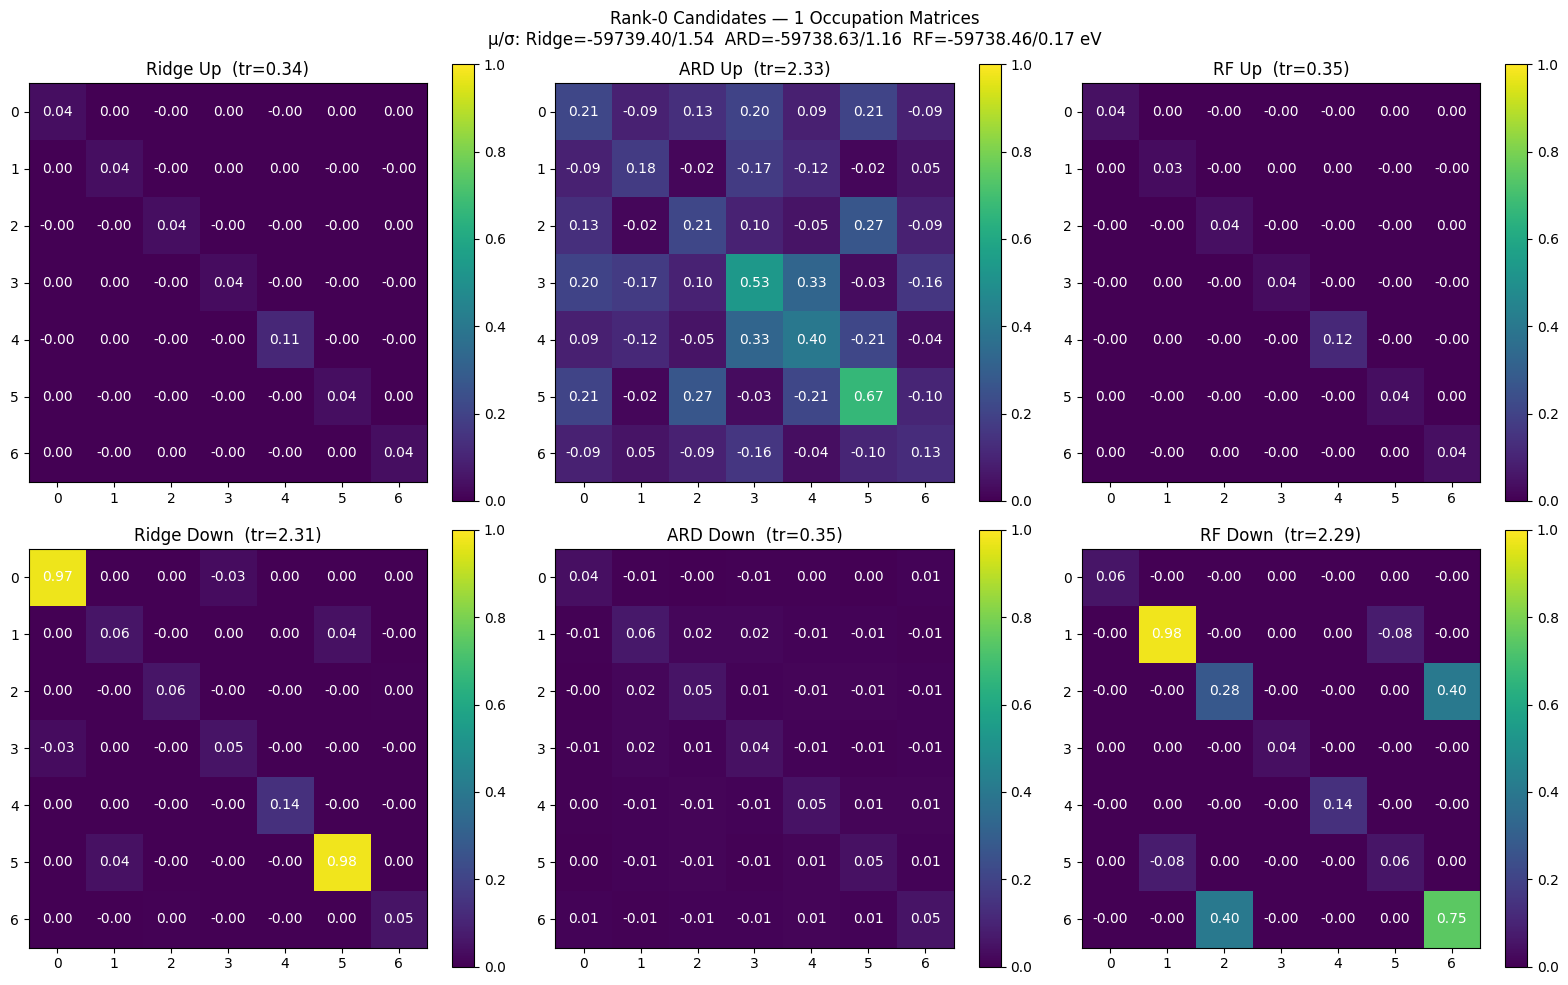


--- Ridge ---
  1:  tr=2.647  M=-1.971
    eig up:   [0.035 0.035 0.035 0.038 0.041 0.041 0.113]
    eig down: [0.049 0.051 0.053 0.058 0.14  0.976 0.982]
  2:  tr=2.654  M=1.962
    eig up:   [0.041 0.043 0.058 0.063 0.137 0.979 0.987]
    eig down: [0.033 0.034 0.036 0.041 0.042 0.046 0.114]
  3:  tr=2.645  M=-1.927
    eig up:   [0.034 0.035 0.038 0.039 0.047 0.051 0.115]
    eig down: [0.04  0.044 0.049 0.052 0.139 0.978 0.984]
  4:  tr=2.651  M=-1.949
    eig up:   [0.035 0.036 0.037 0.041 0.042 0.046 0.114]
    eig down: [0.041 0.043 0.051 0.062 0.143 0.979 0.981]

--- ARD ---
  1:  tr=2.673  M=1.981
    eig up:   [0.04  0.041 0.056 0.11  0.133 0.959 0.988]
    eig down: [0.032 0.034 0.035 0.035 0.045 0.053 0.112]
  2:  tr=2.672  M=2.000
    eig up:   [0.045 0.058 0.062 0.063 0.127 0.99  0.991]
    eig down: [0.03  0.03  0.034 0.041 0.046 0.047 0.108]
  3:  tr=2.659  M=-1.991
    eig up:   [0.031 0.034 0.035 0.039 0.041 0.043 0.111]
    eig down: [0.044 0.057 0.058 0.063 0.138 0

In [21]:
# Compare rank-0 (best) candidate from each model
to_visualize_idx = 0

best = {
    "Ridge": (ensamble_occ[idx_ridge[to_visualize_idx]], mu_r[idx_ridge[to_visualize_idx]], sig_r[idx_ridge[to_visualize_idx]]),
    "ARD":   (ensamble_occ[idx_ard[to_visualize_idx]],   mu_a[idx_ard[to_visualize_idx]],   sig_a[idx_ard[to_visualize_idx]]),
    "RF":    (ensamble_occ[idx_rf[to_visualize_idx]],    mu_f[idx_rf[to_visualize_idx]],    sig_f[idx_rf[to_visualize_idx]]),
}

print(f"{'Model':<8} {'μ (eV)':<12} {'σ (eV)':<12}")
print("-" * 32)
for name, (occ, mu, sigma) in best.items():
    print(f"{name:<8} {mu:<12.4f} {sigma:<12.4f}")

# Side-by-side heatmaps for the first atom
atom_id = atoms[0]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for col, (name, (occ, mu, sigma)) in enumerate(best.items()):
    up_mat = np.array(occ.get_occupation_matrix(atom_id, 'up'))
    down_mat = np.array(occ.get_occupation_matrix(atom_id, 'down'))
    
    for row, (mat, spin) in enumerate([(up_mat, 'Up'), (down_mat, 'Down')]):
        ax = axes[row, col]
        im = ax.imshow(np.abs(mat), cmap='viridis', vmin=0, vmax=1)
        tr = np.trace(mat)
        ax.set_title(f'{name} {spin}  (tr={tr:.2f})')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='w')
        fig.colorbar(im, ax=ax)

plt.suptitle(f"Rank-0 Candidates — {atom_id} Occupation Matrices\n"
             f"μ/σ: Ridge={mu_r[idx_ridge[0]]:.2f}/{sig_r[idx_ridge[0]]:.2f}  "
             f"ARD={mu_a[idx_ard[0]]:.2f}/{sig_a[idx_ard[0]]:.2f}  "
             f"RF={mu_f[idx_rf[0]]:.2f}/{sig_f[idx_rf[0]]:.2f} eV",
             fontsize=12)
plt.tight_layout()
plt.show()

# Print eigenvalues for all atoms
for name, (occ, mu, sigma) in best.items():
    print(f"\n--- {name} ---")
    for atom_id in atoms:
        up_mat = np.array(occ.get_occupation_matrix(atom_id, 'up'))
        down_mat = np.array(occ.get_occupation_matrix(atom_id, 'down'))
        print(f"  {atom_id}:  tr={np.trace(up_mat)+np.trace(down_mat):.3f}  "
              f"M={np.trace(up_mat)-np.trace(down_mat):.3f}")
        print(f"    eig up:   {np.round(np.linalg.eigvalsh(up_mat), 3)}")
        print(f"    eig down: {np.round(np.linalg.eigvalsh(down_mat), 3)}")

## Novelty Analysis

In [ ]:
# Compute distances from best ridge candidate to all training examples
candidate_occ = best["Ridge"][0]

distances = train_db.compute_distances(
    reference=candidate_occ,
    atom_label=None,
    spins=['up', 'down']
)

print(f"Novelty Metrics (Ridge best candidate):")
print(f"  Min distance to training: {distances.min():.6f}")
print(f"  Mean distance: {distances.mean():.6f}")
print(f"  Median distance: {np.median(distances):.6f}")

plt.figure(figsize=(10, 5))
plt.hist(distances, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(distances.min(), color='red', linestyle='--', linewidth=2, label=f'Candidate (min={distances.min():.4f})')
plt.xlim(0, distances.max() * 1.05)
plt.xlabel("Distance to Candidate")
plt.ylabel("Count")
plt.title("Distribution of Training Set Distances to Proposed Candidate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Closest Training Example vs Candidate

In [ ]:
# Compare candidate vs closest training example
closest_idx = np.argmin(distances)
closest_occ = train_db.get_occ_data(closest_idx)

print(f"Closest training example index: {idx_train[closest_idx]} (distance = {distances.min():.6f})")
print(f"=== Candidate vs Closest Training ===")

for atom_id in atoms:
    up_closest = np.array(closest_occ.get_occupation_matrix(atom_id, 'up'))
    down_closest = np.array(closest_occ.get_occupation_matrix(atom_id, 'down'))
    up_cand = np.array(candidate_occ.get_occupation_matrix(atom_id, 'up'))
    down_cand = np.array(candidate_occ.get_occupation_matrix(atom_id, 'down'))

    print(f"\n{atom_id}:")
    print(f"  Closest trace: {np.trace(up_closest)+np.trace(down_closest):.3f}")
    print(f"  Candidate trace: {np.trace(up_cand)+np.trace(down_cand):.3f}")

    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    for idx, (mat, title) in enumerate([
        (up_closest, 'Closest Up'), (down_closest, 'Closest Down'),
        (up_cand, 'Candidate Up'), (down_cand, 'Candidate Down')]):
        ax = axs[idx // 2, idx % 2]
        im = ax.imshow(np.abs(mat), cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'{atom_id} {title}')
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(j, i, f"{mat[i,j]:.2f}", ha='center', va='center', color='w')
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()